In [6]:
import itertools
import logging
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random

from modules import background_model, model, ModelDataSet, plotting, ProfileFindingSetup, SequenceRepresentation, utils

logging.basicConfig(level=logging.DEBUG, format='%(asctime)s - %(levelname)s - %(message)s')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

np.set_printoptions(precision=4, suppress=True) # Suppress scientific notation for small numbers for better readability

In [7]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


Old vs. New implementation

In [8]:
# fasta = Path("/home/ebelm/brain/genomegraph/data/20250408_STREME_benchmark_revisited/diluted_dataset/1.00/primary_sequences/wgEncodeAwgTfbsBroadK562CtcfUniPk.narrowPeak.fasta")
# sim_fasta = Path("/home/ebelm/brain/genomegraph/data/20250408_STREME_benchmark_revisited/simulated_dataset/order_2/wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak/1.00/primary_sequences/wgEncodeAwgTfbsSIMULATED.fasta")

fasta = Path("/home/matthis/PhD/genomegraph/learn_specific_profiles/.brain_mnt/data/20250408_STREME_benchmark_revisited/diluted_dataset/1.00/primary_sequences/wgEncodeAwgTfbsBroadK562CtcfUniPk.narrowPeak.fasta")
sim_fasta = Path("/home/matthis/PhD/genomegraph/learn_specific_profiles/.brain_mnt/data/20250408_STREME_benchmark_revisited/simulated_dataset/order_2/wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak/1.00/primary_sequences/wgEncodeAwgTfbsSIMULATED.fasta")

In [9]:
genomes = [SequenceRepresentation.Genome([seq]) for seq in SequenceRepresentation.loadFasta_agnostic(fasta)]

In [10]:
len(genomes)

51992

In [ ]:
data = ModelDataSet.ModelDataSet(genomes[:1000], ModelDataSet.DataMode.DNA, tile_size=100, tiles_per_X=1, batch_size=1, prefetch=3)

In [ ]:
bgmodel = background_model.TrainedQ(data, num_models=1, order=0, rand_seed=SEED)

In [ ]:
losses = bgmodel.train(lr=0.01, lr_factor=0.75, lr_patience=10, epochs=50)

In [ ]:
# plot losses
def plot_losses(name: str, losses: list[float]):
    plt.plot(losses, label=f'Losses for Model {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss for {name}')
    plt.legend()
    plt.show()

In [ ]:
plot_losses("new implementation", losses)

In [ ]:
bgmodel.getQ().numpy()[0]

In [ ]:
bgmodel.get_avg_Q()

In [ ]:
assert np.allclose(bgmodel.getQ().numpy()[0], bgmodel.get_avg_Q()), \
    f"Q matrix {bgmodel.getQ().numpy()[0]} and average Q {bgmodel.get_avg_Q()} do not match, diff: {bgmodel.getQ().numpy()[0] - bgmodel.get_avg_Q()}"

`Q` and `get_avg_Q` are the same for K=1 and order=0, as expected. Thus, a training with new and old implementation should be equivalent

In [ ]:
tf.keras.backend.clear_session() # avoid memory cluttering by remains of old models

In [ ]:
setup = ProfileFindingSetup.ProfileFindingTrainingSetup(
    data=data,
    U=200, k=12, midK=8, s=0,
    epochs=200, gamma=1.0, l2=0.1, kld=0.0, mellowmax_alpha=1.0,
    match_score_factor=0.7, learning_rate=2.0, lr_patience=5, lr_factor=0.75,
    rho=0.0, sigma=1.0, profile_plateau=10, profile_plateau_dev=150,
    n_best_profiles=5,
    phylo_t=0.0,
    Q_order=0, Q_num_models=1, Q_learning_rate=0.01, Q_lr_patience=10, Q_lr_factor=0.75, Q_epochs=50, Q_rand_seed=SEED,
    Q = bgmodel,
)

In [ ]:
tf.config.run_functions_eagerly(True) # needed because otherwise bgmodel.get_avg_Q() will fail because the Tensor.numpy() method is prohibited

In [ ]:
legacy_model = model.SpecificProfile(setup, rand_seed=SEED)
legacy_model.legacy_Z = True

---

Debug this

In [32]:
tf.config.run_functions_eagerly(True) # needed because otherwise bgmodel.get_avg_Q() will fail because the Tensor.numpy() method is prohibited

In [11]:
dbg_seq = genomes[0].getSequenceStrings()[0][:17]  # Use a shorter sequence for debugging
dbg_seq

'GAAGCCTCGCCGGAACT'

In [12]:
dbg_genome = SequenceRepresentation.Genome([SequenceRepresentation.Sequence('dbg', 'cho0', '+', 0, sequence=dbg_seq)])
dbg_genomes = [dbg_genome, dbg_genome] # otherwise error: need at least two genomes for training
dbg_data = ModelDataSet.ModelDataSet(dbg_genomes, ModelDataSet.DataMode.DNA, tile_size=len(dbg_seq), tiles_per_X=1, batch_size=1, prefetch=1)
dbg_bgmodel = background_model.TrainedQ(dbg_data, num_models=1, order=0, rand_seed=SEED) # no need to train
dbg_bgmodel.Q_logit = tf.Variable(np.array([[0,1,1,0]], dtype=np.float32), trainable=True)
print(dbg_bgmodel.getQ().numpy())

2025-07-18 13:54:14,050 - DEBUG - [TrainedQ.__init__] >>> setting tf global seed to 42
2025-07-18 13:54:14,089 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)


[[0.1345 0.3655 0.3655 0.1345]]


In [13]:
dbg_setup = ProfileFindingSetup.ProfileFindingTrainingSetup(
    data=dbg_data,
    U=1, k=12, midK=8, s=0,
    epochs=200, gamma=1.0, l2=0.1, kld=0.0, mellowmax_alpha=1.0,
    match_score_factor=0.7, learning_rate=2.0, lr_patience=5, lr_factor=0.75,
    rho=0.0, sigma=1.0, profile_plateau=10, profile_plateau_dev=150,
    n_best_profiles=5,
    phylo_t=0.0,
    Q_order=0, Q_num_models=1, Q_learning_rate=0.01, Q_lr_patience=10, Q_lr_factor=0.75, Q_epochs=50, Q_rand_seed=SEED,
    Q = dbg_bgmodel,
)

dbg_model = model.SpecificProfile(dbg_setup, rand_seed=SEED)

2025-07-18 13:54:14,406 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-07-18 13:54:14.509908: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [14]:
Xfwd = utils.oneHot(dbg_seq, dbg_setup.data.alphabet)
Xrc = utils.oneHot(dbg_seq[::-1].translate(utils._rctbl), dbg_setup.data.alphabet)
X0 = np.stack([Xfwd, Xrc], axis=0, dtype=np.float32)  # shape
X1 = X0.copy()
X = np.stack([X0, X1], axis=0)
print(X.shape)

(2, 2, 17, 4)


In [15]:
# bring X to shape (B, ntiles, N=2, f=2, 12, 4) where B, ntiles are 1
X = X.reshape((1, 1, 2, 2, len(dbg_seq), 4))
print(X.shape)

(1, 1, 2, 2, 17, 4)


In [16]:
P = dbg_model.getP()
P.shape

TensorShape([12, 4, 1])

In [17]:
P

<tf.Tensor: shape=(12, 4, 1), dtype=float32, numpy=
array([[[0.0334],
        [0.0004],
        [0.5407],
        [0.4255]],

       [[0.0001],
        [0.0031],
        [0.9384],
        [0.0584]],

       [[0.0081],
        [0.0008],
        [0.7961],
        [0.195 ]],

       [[0.0049],
        [0.9286],
        [0.0663],
        [0.0001]],

       [[0.0453],
        [0.0006],
        [0.9456],
        [0.0085]],

       [[0.0013],
        [0.0005],
        [0.9967],
        [0.0015]],

       [[0.0064],
        [0.0237],
        [0.8159],
        [0.154 ]],

       [[0.0004],
        [0.0011],
        [0.9986],
        [0.    ]],

       [[0.001 ],
        [0.0008],
        [0.2584],
        [0.7398]],

       [[0.0443],
        [0.0066],
        [0.007 ],
        [0.9421]],

       [[0.4237],
        [0.5173],
        [0.0041],
        [0.0549]],

       [[0.0161],
        [0.0657],
        [0.8937],
        [0.0246]]], dtype=float32)>

In [18]:
Z_legacy, R_legacy = dbg_model.getZ_legacy(X, P)
Z_new = dbg_model.getZ(X, P)

In [19]:
assert Z_legacy.shape == Z_new.shape, f"Z_legacy shape {Z_legacy.shape} and Z_new shape {Z_new.shape} do not match"

In [20]:
Z_legacy[0,0,0]

<tf.Tensor: shape=(2, 6, 1), dtype=float32, numpy=
array([[[-33.3287],
        [-33.363 ],
        [-36.7088],
        [-36.7977],
        [-19.6611],
        [-33.9848]],

       [[-26.2701],
        [-14.6207],
        [-19.6947],
        [-27.902 ],
        [-26.8634],
        [-12.7178]]], dtype=float32)>

In [21]:
Z_new[0,0,0]

<tf.Tensor: shape=(2, 6, 1), dtype=float32, numpy=
array([[[-33.3287],
        [-33.363 ],
        [-36.7088],
        [-36.7977],
        [-19.6611],
        [-33.9848]],

       [[-26.2701],
        [-14.6207],
        [-19.6947],
        [-27.902 ],
        [-26.8634],
        [-12.7178]]], dtype=float32)>

In [22]:
assert np.allclose(Z_legacy, Z_new), f"Z_legacy {Z_legacy} and Z_new {Z_new} do not match, diff: {Z_legacy - Z_new}"

In [23]:
# what happens when Q differs?
dbg_bgmodel_2 = background_model.TrainedQ(dbg_data, num_models=1, order=0, rand_seed=SEED) # no need to train
dbg_bgmodel_2.Q_logit = tf.Variable(np.array([[1,0,0,1]], dtype=np.float32), trainable=True)
print(dbg_bgmodel_2.getQ().numpy())

dbg_setup_2 = ProfileFindingSetup.ProfileFindingTrainingSetup(
    data=dbg_data,
    U=1, k=12, midK=8, s=0,
    epochs=200, gamma=1.0, l2=0.1, kld=0.0, mellowmax_alpha=1.0,
    match_score_factor=0.7, learning_rate=2.0, lr_patience=5, lr_factor=0.75,
    rho=0.0, sigma=1.0, profile_plateau=10, profile_plateau_dev=150,
    n_best_profiles=5,
    phylo_t=0.0,
    Q_order=0, Q_num_models=1, Q_learning_rate=0.01, Q_lr_patience=10, Q_lr_factor=0.75, Q_epochs=50, Q_rand_seed=SEED,
    Q = dbg_bgmodel_2,
)

dbg_model_2 = model.SpecificProfile(dbg_setup_2, rand_seed=SEED)

2025-07-18 13:54:19,131 - DEBUG - [TrainedQ.__init__] >>> setting tf global seed to 42
2025-07-18 13:54:19,147 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)
2025-07-18 13:54:19,161 - DEBUG - [model.__init__] >>> setting tf global seed to 42


[[0.3655 0.1345 0.1345 0.3655]]


2025-07-18 13:54:19.268497: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [24]:
P = dbg_model_2.getP()
Z_new_2 = dbg_model_2.getZ(X, P)

In [25]:
assert Z_new.shape == Z_new_2.shape, f"Z_legacy shape {Z_legacy.shape} and Z_new shape {Z_new.shape} do not match"

In [26]:
Z_new[0,0,0]

<tf.Tensor: shape=(2, 6, 1), dtype=float32, numpy=
array([[[-33.3287],
        [-33.363 ],
        [-36.7088],
        [-36.7977],
        [-19.6611],
        [-33.9848]],

       [[-26.2701],
        [-14.6207],
        [-19.6947],
        [-27.902 ],
        [-26.8634],
        [-12.7178]]], dtype=float32)>

In [27]:
Z_new_2[0,0,0]

<tf.Tensor: shape=(2, 6, 1), dtype=float32, numpy=
array([[[-30.2662],
        [-30.3005],
        [-33.6463],
        [-33.7353],
        [-16.5986],
        [-30.9224]],

       [[-23.2076],
        [-11.5582],
        [-16.6322],
        [-24.8395],
        [-23.8009],
        [ -9.6553]]], dtype=float32)>

For tiny X, a single P and a single, 0-order Q, the old and new implementation yield the same Z, as desired. If Q 
changes, Z changes as well, as desired.

Check the loss and gradients, maybe there are differences there?

In [28]:
dbg_model_legacy = model.SpecificProfile(dbg_setup, rand_seed=SEED)
dbg_model_legacy.legacy_Z = True

2025-07-18 13:54:22,133 - DEBUG - [model.__init__] >>> setting tf global seed to 42


In [29]:
dbg_model.debug_mode = True
S, R, loss, grad = dbg_model.train_step(X)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2025-07-18 13:54:23,568 - DEBUG - [model.getZ] >>> nan in X
2025-07-18 13:54:24,401 - WARNING - AutoGraph could not transform <bound method Socket.send of <zmq.Socket(zmq.PUSH) at 0x7454952b1720>> and will run it as-is.
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2025-07-18 13:54:24,730 - DEBUG - [model.getZ] >>> nan in Z
2025-07-18 13:54:25,297 - DEBUG - [model.getZ] >>> nan in X
2025-07-18 13:54:25,322 - DEBUG - [model.getZ] >>> nan in Z


In [33]:
dbg_model_legacy.debug_mode = True
S_legacy, R_legacy, loss_legacy, grad_legacy = dbg_model_legacy.train_step(X)

In [34]:
S

<tf.Tensor: shape=(1, 1, 2, 1), dtype=float32, numpy=
array([[[[-12.7178],
         [-12.7178]]]], dtype=float32)>

In [35]:
S_legacy

<tf.Tensor: shape=(1, 1, 2, 1), dtype=float32, numpy=
array([[[[-12.7178],
         [-12.7178]]]], dtype=float32)>

In [36]:
loss

<tf.Tensor: shape=(), dtype=float32, numpy=4.512325763702393>

In [37]:
loss_legacy

<tf.Tensor: shape=(), dtype=float32, numpy=4.512325763702393>

In [38]:
grad

<tf.Tensor: shape=(12, 4, 1), dtype=float32, numpy=
array([[[-0.0131],
        [-0.0861],
        [ 0.0333],
        [ 0.0293]],

       [[-0.1635],
        [-0.1036],
        [-0.0083],
        [-0.0545]],

       [[-0.0346],
        [-0.0736],
        [ 0.0419],
        [ 0.0184]],

       [[-0.029 ],
        [ 0.0584],
        [ 0.0144],
        [-0.0907]],

       [[-0.0089],
        [-0.0807],
        [ 0.0418],
        [-0.0368]],

       [[-0.0458],
        [-0.0622],
        [ 0.0647],
        [-0.0437]],

       [[-0.062 ],
        [-0.0402],
        [ 0.0187],
        [-0.0091]],

       [[-0.0059],
        [ 0.0119],
        [ 0.126 ],
        [-0.0605]],

       [[-0.0676],
        [-0.071 ],
        [ 0.0243],
        [ 0.0418]],

       [[-0.041 ],
        [-0.0728],
        [-0.0717],
        [ 0.0099]],

       [[ 0.0161],
        [ 0.0194],
        [-0.0611],
        [-0.018 ]],

       [[-0.0257],
        [-0.0022],
        [ 0.0413],
        [-0.0185]]], dtype=float3

In [39]:
grad_legacy

<tf.Tensor: shape=(12, 4, 1), dtype=float32, numpy=
array([[[-0.0131],
        [-0.0861],
        [ 0.0333],
        [ 0.0293]],

       [[-0.1635],
        [-0.1036],
        [-0.0083],
        [-0.0545]],

       [[-0.0346],
        [-0.0736],
        [ 0.0419],
        [ 0.0184]],

       [[-0.029 ],
        [ 0.0584],
        [ 0.0144],
        [-0.0907]],

       [[-0.0089],
        [-0.0807],
        [ 0.0418],
        [-0.0368]],

       [[-0.0458],
        [-0.0622],
        [ 0.0647],
        [-0.0437]],

       [[-0.062 ],
        [-0.0402],
        [ 0.0187],
        [-0.0091]],

       [[-0.0059],
        [ 0.0119],
        [ 0.126 ],
        [-0.0605]],

       [[-0.0676],
        [-0.071 ],
        [ 0.0243],
        [ 0.0418]],

       [[-0.041 ],
        [-0.0728],
        [-0.0717],
        [ 0.0099]],

       [[ 0.0161],
        [ 0.0194],
        [-0.0611],
        [-0.018 ]],

       [[-0.0257],
        [-0.0022],
        [ 0.0413],
        [-0.0185]]], dtype=float3

This also is equal.

Try a small training run with both implementations, the resulting profiles should be the same, then.

In [41]:
dbg_seq = genomes[0].getSequenceStrings()[0][:17]  # Use a shorter sequence for debugging

dbg_genome = SequenceRepresentation.Genome([SequenceRepresentation.Sequence('dbg', 'cho0', '+', 0, sequence=dbg_seq)])
dbg_genomes = [dbg_genome, dbg_genome] # otherwise error: need at least two genomes for training
dbg_data = ModelDataSet.ModelDataSet(dbg_genomes, ModelDataSet.DataMode.DNA, tile_size=len(dbg_seq), tiles_per_X=1, batch_size=1, prefetch=1)
dbg_bgmodel = background_model.TrainedQ(dbg_data, num_models=1, order=0, rand_seed=SEED) # no need to train
dbg_bgmodel.Q_logit = tf.Variable(np.array([[0,1,1,0]], dtype=np.float32), trainable=True)

dbg_setup = ProfileFindingSetup.ProfileFindingTrainingSetup(
    data=dbg_data,
    U=1, k=12, midK=8, s=0,
    epochs=200, gamma=1.0, l2=0.1, kld=0.0, mellowmax_alpha=1.0,
    match_score_factor=0.7, learning_rate=2.0, lr_patience=5, lr_factor=0.75,
    rho=0.0, sigma=1.0, profile_plateau=10, profile_plateau_dev=150,
    n_best_profiles=2,
    phylo_t=0.0,
    Q_order=0, Q_num_models=1, Q_learning_rate=0.01, Q_lr_patience=10, Q_lr_factor=0.75, Q_epochs=50, Q_rand_seed=SEED,
    Q = dbg_bgmodel,
)

tf.keras.backend.clear_session() # avoid memory cluttering by remains of old models

dbg_model = model.SpecificProfile(dbg_setup, rand_seed=SEED)
dbg_model_legacy = model.SpecificProfile(dbg_setup, rand_seed=SEED)
dbg_model_legacy.legacy_Z = True

2025-07-18 13:55:00,787 - DEBUG - [TrainedQ.__init__] >>> setting tf global seed to 42
2025-07-18 13:55:00,805 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)
2025-07-18 13:55:01,133 - DEBUG - [model.__init__] >>> setting tf global seed to 42
/home/matthis/PhD/genomegraph/.venv/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
2025-07-18 13:55:01.221517: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-07-18 13:55:01,229 - DEBUG - [model.__init__] >>> setting tf global seed to 42


In [42]:
dbg_model_legacy.P_logit = tf.Variable(dbg_model.P_logit.numpy(), trainable=True) # use same initial P in both models

In [43]:
assert np.allclose(dbg_model.P_logit.numpy(), dbg_model_legacy.P_logit.numpy()), \
    f"P_logit {dbg_model.P_logit.numpy()} and legacy P_logit {dbg_model_legacy.P_logit.numpy()} do not match, diff: {dbg_model.P_logit.numpy() - dbg_model_legacy.P_logit.numpy()}"

In [44]:
dbg_model.P_logit[:2]

<tf.Tensor: shape=(2, 4, 1), dtype=float32, numpy=
array([[[-0.7875],
        [-5.1663],
        [ 1.9954],
        [ 1.7558]],

       [[-9.8105],
        [-6.2151],
        [-0.495 ],
        [-3.2714]]], dtype=float32)>

In [45]:
dbg_model_legacy.P_logit[:2]

<tf.Tensor: shape=(2, 4, 1), dtype=float32, numpy=
array([[[-0.7875],
        [-5.1663],
        [ 1.9954],
        [ 1.7558]],

       [[-9.8105],
        [-6.2151],
        [-0.495 ],
        [-3.2714]]], dtype=float32)>

In [46]:
dbg_model.train()

2025-07-18 13:55:08,011 - DEBUG - [model.train.setLR] >>> Setting learning rate to 2.0
2025-07-18 13:55:08,282 - INFO - [model.train] >>> epoch 0 best profile 0 with mean loss 1.7638076543807983
2025-07-18 13:55:08,283 - INFO - [model.train] >>> epoch     0 sum of profile tile losses = 1.7638, max R: 0.000, min R: 0.000, time: 0.20s
2025-07-18 13:55:08.467399: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-07-18 13:55:09.795038: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-07-18 13:55:09,797 - INFO - [model.train] >>> epoch 9 best profile 0 with mean loss -9.79753303527832
2025-07-18 13:55:09,798 - INFO - [model.train] >>> cleaning up profile 0
2025-07-18 13:55:10,206 - DEBUG - [model.train] >>> Resetting training
2025-07-18 13:55:10,208 - DEBUG - [model.train.setLR] >>> Setting learning rate to 2.0
2025-07-18 13:55:10,3

In [47]:
dbg_model.P_logit[:2]

<tf.Tensor: shape=(2, 4, 1), dtype=float32, numpy=
array([[[-7.2972],
        [-4.9954],
        [ 0.5927],
        [-5.6283]],

       [[-3.5191],
        [ 4.1905],
        [-2.4315],
        [ 0.9437]]], dtype=float32)>

In [48]:
dbg_model_legacy.P_logit[:2]

<tf.Tensor: shape=(2, 4, 1), dtype=float32, numpy=
array([[[-0.7875],
        [-5.1663],
        [ 1.9954],
        [ 1.7558]],

       [[-9.8105],
        [-6.2151],
        [-0.495 ],
        [-3.2714]]], dtype=float32)>

In [49]:
assert not np.allclose(dbg_model.P_logit.numpy(), dbg_model_legacy.P_logit.numpy()), \
    f"P_logit {dbg_model.P_logit.numpy()} and legacy P_logit {dbg_model_legacy.P_logit.numpy()} should not match!"

In [50]:
dbg_model_legacy.train()

2025-07-18 13:55:12,221 - DEBUG - [model.train.setLR] >>> Setting learning rate to 2.0
2025-07-18 13:55:12,550 - INFO - [model.train] >>> epoch 0 best profile 0 with mean loss 1.7638076543807983
2025-07-18 13:55:12,552 - INFO - [model.train] >>> epoch     0 sum of profile tile losses = 1.7638, max R: 1.947, min R: -9.187, time: 0.23s
2025-07-18 13:55:13,921 - INFO - [model.train] >>> epoch 9 best profile 0 with mean loss -2.158722400665283
2025-07-18 13:55:13,922 - INFO - [model.train] >>> cleaning up profile 0
2025-07-18 13:55:14,309 - DEBUG - [model.train] >>> Resetting training
2025-07-18 13:55:14,310 - DEBUG - [model.train.setLR] >>> Setting learning rate to 2.0
2025-07-18 13:55:14,312 - INFO - [model.train_reporting.reduceLR] >>> Loss did not decrease for 5 epochs, reducing learning rate from 2.0 to 1.5
2025-07-18 13:55:14,312 - DEBUG - [model.train.setLR] >>> Setting learning rate to 1.5
2025-07-18 13:55:15,064 - INFO - [model.train_reporting.reduceLR] >>> Loss did not decrease f

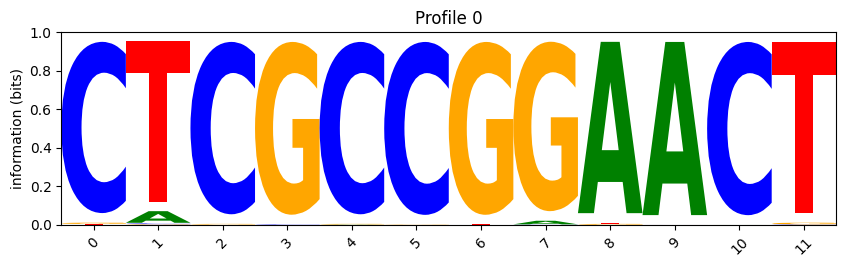

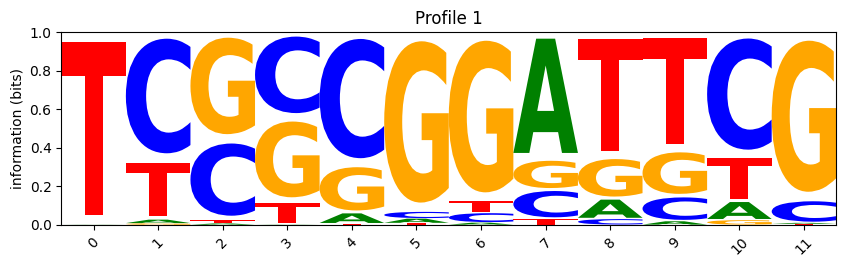

In [53]:
plotting.plotLogo(dbg_model.profile_report.P, dbg_setup.data.alphabet)

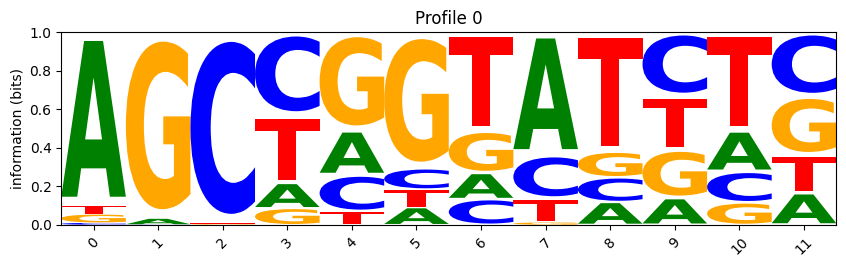

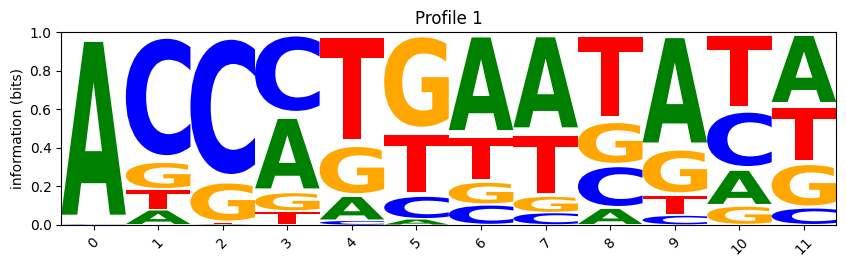

In [54]:
# ^^^ new implementation ^^^ || vvv legacy implementation vvv
plotting.plotLogo(dbg_model_legacy.profile_report.P, dbg_setup.data.alphabet)

This is odd, Z, loss, gradients are the same for the same input, P and Q, but the model parameters are not the same 
after training.

Next: do a step-by-step and side-by-side training manually, and track when the parameters diverge.

In [114]:
dbg_seq = genomes[0].getSequenceStrings()[0]#[:17]  # Use a shorter sequence for debugging

dbg_genome = SequenceRepresentation.Genome([SequenceRepresentation.Sequence('dbg', 'cho0', '+', 0, sequence=dbg_seq)])
dbg_genomes = [dbg_genome, dbg_genome] # otherwise error: need at least two genomes for training
dbg_data = ModelDataSet.ModelDataSet(dbg_genomes, ModelDataSet.DataMode.DNA, tile_size=len(dbg_seq), tiles_per_X=1, batch_size=1, prefetch=1)
dbg_bgmodel = background_model.TrainedQ(dbg_data, num_models=1, order=0, rand_seed=SEED) # no need to train
dbg_bgmodel.Q_logit = tf.Variable(np.array([[0,1,1,0]], dtype=np.float32), trainable=True)

dbg_setup = ProfileFindingSetup.ProfileFindingTrainingSetup(
    data=dbg_data,
    U=1, k=12, midK=8, s=0,
    epochs=200, gamma=1.0, l2=0.1, kld=0.0, mellowmax_alpha=1.0,
    match_score_factor=0.7, learning_rate=2.0, lr_patience=5, lr_factor=0.75,
    rho=0.0, sigma=1.0, profile_plateau=10, profile_plateau_dev=150,
    n_best_profiles=2,
    phylo_t=0.0,
    Q_order=0, Q_num_models=1, Q_learning_rate=0.01, Q_lr_patience=10, Q_lr_factor=0.75, Q_epochs=50, Q_rand_seed=SEED,
    Q = dbg_bgmodel,
)

tf.keras.backend.clear_session() # avoid memory cluttering by remains of old models

dbg_model = model.SpecificProfile(dbg_setup, rand_seed=SEED)
dbg_model_legacy = model.SpecificProfile(dbg_setup, rand_seed=SEED)
dbg_model_legacy.legacy_Z = True

dbg_model.debug_mode = True
dbg_model_legacy.debug_mode = True

dbg_model_legacy.P_logit = tf.Variable(dbg_model.P_logit.numpy(), trainable=True) # use same initial P in both models

2025-07-18 14:23:09,192 - DEBUG - [TrainedQ.__init__] >>> setting tf global seed to 42
2025-07-18 14:23:09,241 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)
2025-07-18 14:23:10,030 - DEBUG - [model.__init__] >>> setting tf global seed to 42
/home/matthis/PhD/genomegraph/.venv/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
2025-07-18 14:23:10,140 - DEBUG - [model.__init__] >>> setting tf global seed to 42


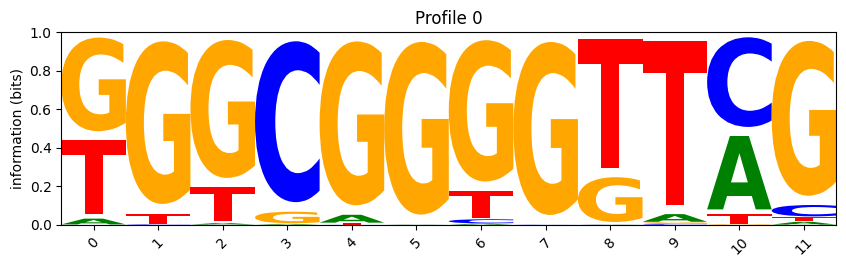

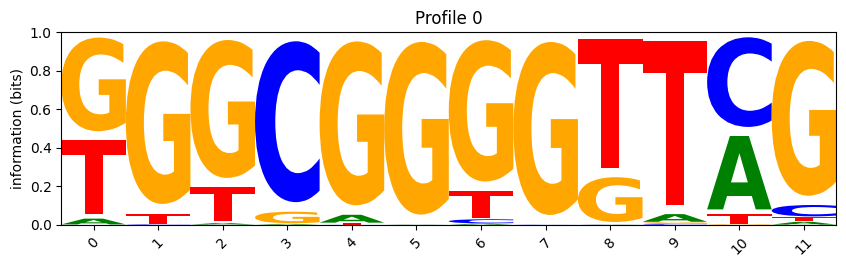

In [115]:
plotting.plotLogo(dbg_model.getP(), dbg_setup.data.alphabet)
plotting.plotLogo(dbg_model_legacy.getP(), dbg_setup.data.alphabet)

In [116]:
Xfwd = utils.oneHot(dbg_seq, dbg_setup.data.alphabet)
Xrc = utils.oneHot(dbg_seq[::-1].translate(utils._rctbl), dbg_setup.data.alphabet)
X0 = np.stack([Xfwd, Xrc], axis=0, dtype=np.float32)  # shape
X1 = X0.copy()
X = np.stack([X0, X1], axis=0)
X = X.reshape((1, 1, 2, 2, len(dbg_seq), 4)) # bring X to shape (B, ntiles, N=2, f=2, 12, 4) where B, ntiles are 1

In [117]:
ds = dbg_data.getDataset()
X_ds = next(iter(ds))[0]  # get the first batch from the dataset
print(X_ds.shape)

assert np.array_equal(X_ds.numpy(), X), "X_ds and X do not match"   

(1, 1, 2, 2, 100, 4)


/home/matthis/PhD/genomegraph/.venv/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


In [118]:
for i in range(100):
    cont = True
    S, _, loss, grad = dbg_model.train_step(X)
    S_legacy, _, loss_legacy, grad_legacy = dbg_model_legacy.train_step(X)
    
    mean_loss = dbg_model.get_mean_losses(dbg_data.getDataset(withPosTracking=True), 
                                          dbg_model.getP(), dbg_model.P_logit)
    mean_loss_legacy = dbg_model_legacy.get_mean_losses(dbg_data.getDataset(withPosTracking=True), 
                                                        dbg_model_legacy.getP(), dbg_model_legacy.P_logit)
    for atol, abort in [(1e-3, True), (1e-6, False), (1e-10, False)]:
        diff = False
        if not np.allclose(S.numpy(), S_legacy.numpy(), atol=atol):
            if abort:
                print(f"[epoch {i}] S {S.numpy()} and legacy S {S_legacy.numpy()} do not match, diff: {S.numpy() - S_legacy.numpy()}")
                diff = True
            else:
                diff = True
        if not np.allclose(loss.numpy(), loss_legacy.numpy(), atol=atol):
            if abort:
                print(f"[epoch {i}] Loss {loss.numpy()} and legacy Loss {loss_legacy.numpy()} do not match, diff: {loss.numpy() - loss_legacy.numpy()}")
                diff = True
            else:
                diff = True
        if not np.allclose(grad.numpy(), grad_legacy.numpy(), atol=atol):
            if abort:
                print(f"[epoch {i}] Grad {grad.numpy()} and legacy Grad {grad_legacy.numpy()} do not match, diff: {grad.numpy() - grad_legacy.numpy()}")
                diff = True
            else:
                diff = True

        # check if P_logit is still the same
        if not np.allclose(dbg_model.P_logit.numpy(), dbg_model_legacy.P_logit.numpy(), atol=atol):
            if abort:
                print(f"[epoch {i}] P_logit {dbg_model.P_logit.numpy()} and legacy P_logit {dbg_model_legacy.P_logit.numpy()} do not match, diff: {dbg_model.P_logit.numpy() - dbg_model_legacy.P_logit.numpy()}")
                diff = True
            else:
                diff = True

        # check mean_losses
        if not np.allclose(mean_loss.numpy(), mean_loss_legacy.numpy(), atol=atol):
            if abort:
                print(f"[epoch {i}] Mean Loss {mean_loss.numpy()} and legacy Mean Loss {mean_loss_legacy.numpy()} do not match, diff: {mean_loss.numpy() - mean_loss_legacy.numpy()}")
                diff = True
            else:
                diff = True

        if diff:
            print(f"[epoch {i}] Parameters diverged with tolerance {atol}")
            if abort:
                cont = False

    if not cont:            
        print("stopping training")
        break

[epoch 1] Parameters diverged with tolerance 1e-10
[epoch 2] Parameters diverged with tolerance 1e-10
[epoch 3] Parameters diverged with tolerance 1e-10
[epoch 4] Parameters diverged with tolerance 1e-10
[epoch 5] Parameters diverged with tolerance 1e-10
[epoch 6] Parameters diverged with tolerance 1e-10
[epoch 7] Parameters diverged with tolerance 1e-06
[epoch 7] Parameters diverged with tolerance 1e-10
[epoch 8] Parameters diverged with tolerance 1e-06
[epoch 8] Parameters diverged with tolerance 1e-10
[epoch 9] Parameters diverged with tolerance 1e-10
[epoch 10] Parameters diverged with tolerance 1e-06
[epoch 10] Parameters diverged with tolerance 1e-10
[epoch 11] Parameters diverged with tolerance 1e-06
[epoch 11] Parameters diverged with tolerance 1e-10
[epoch 12] Parameters diverged with tolerance 1e-06
[epoch 12] Parameters diverged with tolerance 1e-10
[epoch 13] Parameters diverged with tolerance 1e-06
[epoch 13] Parameters diverged with tolerance 1e-10
[epoch 14] Parameters d

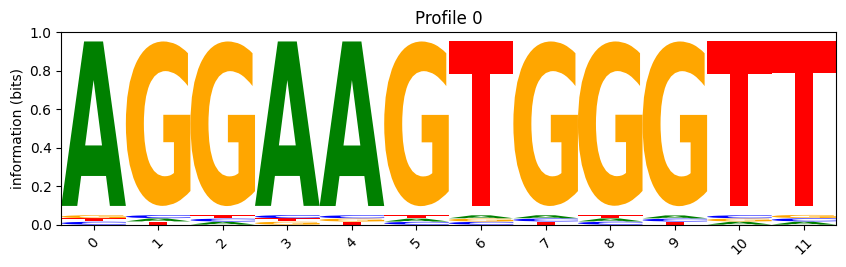

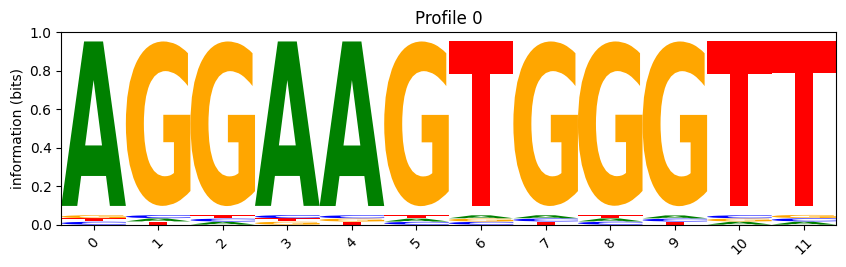

In [119]:
plotting.plotLogo(dbg_model.getP(), dbg_setup.data.alphabet)
plotting.plotLogo(dbg_model_legacy.getP(), dbg_setup.data.alphabet)

---

In [ ]:
legacy_model.train()

In [ ]:
plotting.plotHistory(legacy_model.history)

In [ ]:
plotting.plotLogo(legacy_model.profile_report.P, data.alphabet)

In [ ]:
tf.keras.backend.clear_session() # avoid memory cluttering by remains of old models
new_model = model.SpecificProfile(setup, rand_seed=SEED)
new_model.train()

In [ ]:
plotting.plotHistory(new_model.history)

In [ ]:
plotting.plotLogo(new_model.profile_report.P, data.alphabet)

---

In [ ]:
def from_one_hot(X, k):
    """Convert one-hot encoded tensor to string representation."""
    import itertools
    alphabet = [''.join(p) for p in itertools.product([c for c in 'ACGT'], repeat=k)]
    assert X.shape[-1] == 4**k, "Last dimension must match 4^k for k-mer encoding"
    assert len(X.shape) == 6, "Input tensor must be 6D: (batch_size, tiles_per_X, N, f, tile_size, alphabet_size)"
    for b in range(X.shape[0]):
        for t in range(X.shape[1]):
            for n in range(X.shape[2]):
                for f in range(X.shape[3]):
                    oh = X[b, t, n, f, :, :]
                    idcs = [np.argmax(oh[j,:]) if np.max(oh[j,:]) != 0 else -1 \
                            for j in range(oh.shape[0])]
                    seq = ' '.join([ alphabet[i] if i != -1 else 'N' for i in idcs ])
                    print(f"Batch {b}, Tile {t}, Sequence {n}, Frame {f}: {seq}")
    #return ''.join(['ACGT'[np.argmax(x)] for x in X])

In [ ]:
# quick test of k-mer dataset
raw_data = [
    'ACGT',
    'AACCGGTT',
    'TAACGTAG'
]
data = ModelDataSet.ModelDataSet(
    [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=s)]) \
                                   for i, s in enumerate(raw_data)],
    ModelDataSet.DataMode.DNA,
    tile_size=8,
    tiles_per_X=1,
    batch_size=1,
    prefetch=1,
)

ds = data.getDataset(k=1)
for X, _ in ds:
    assert X.shape == (1,1,3,2,8,4)  # (batch_size, tiles_per_X, len(raw_data), frames, tile_size, alphabet_size)
    print(X.shape)
    print(X[0, 0, :, 0, :, :].numpy())  # Print the first tile, first frame
    from_one_hot(X.numpy(), 1)
    break

In [ ]:
ds = data.getDataset(k=2)
for X, _ in ds:
    assert X.shape == (1,1,3,2,7,16), f"Expected shape {(1,1,2,2,7,16)}, got {X.shape}"  # (batch_size, tiles_per_X, len(raw_data), frames, tile_size, alphabet_size)
    print(X.shape)
    print(X[0, 0, :, 0, :, :].numpy())  # Print the first tile, first frame
    from_one_hot(X, 2)  # Convert to string representation
    break

In [ ]:
ds = data.getDataset(k=3)
for X, _ in ds:
    assert X.shape == (1,1,3,2,6,64)  # (batch_size, tiles_per_X, len(raw_data), frames, tile_size, alphabet_size)
    print(X.shape)
    print(X[0, 0, :, 0, :, :].numpy())  # Print the first tile, first frame
    from_one_hot(X.numpy(), 3)  # Convert to string representation
    break

---

In [ ]:
N = 1000
seqlen = 100
tile_size = 100
batch_size = 1# 32
K = 1

In [ ]:
def generate_data(model: np.ndarray, N: int, seqlen: int, tile_size: int, batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
    assert model.shape == (4,), "Model must be a 4 element vector for ACGT alphabet and zeroth order Markov model."
    # Generate random sequences based on the provided model
    raw_data = []
    for _ in range(N):
        seq = random.choices(alphabet, weights=model, k=seqlen)
        # Join the sequence into a string
        seq_str = ''.join(seq)
        # Append the sequence to the data list
        raw_data.append(seq_str)
    # Create a ModelDataSet object with the generated sequences
    genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq)]) \
               for i, seq in enumerate(raw_data)]
    data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
                                     tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=1)
    assert ''.join(data.alphabet) == "ACGT", \
        f"[generate_data] Alphabet must be ACGT for this model, not {data.alphabet}."
    logging.debug(f"[generate_data] Steps per epoch: {data.getStepsPerEpoch()}.")

    # count the relative frequencies of the nucleotides in the generated sequences for verification
    counts = np.zeros(len(alphabet), dtype=int)
    for seq in raw_data:
        for c in seq:
            assert c in alphabet, \
                f"[generate_data] Sequence contains character {c} not in alphabet {alphabet}." # should not happen
            ci = alphabet.index(c)
            counts[ci] += 1

    # Calculate the relative frequencies
    relative_frequencies = counts / np.sum(counts)
    logging.info(f"[generate_data] Relative frequencies of nucleotides in generated data: {relative_frequencies}")
            
    return data, relative_frequencies

In [ ]:
ground_truth_1 = np.array([0.25, 0.25, 0.25, 0.25])  # Uniform distribution
ground_truth_2 = np.array([0.1, 0.2, 0.3, 0.4])      # Non-uniform distribution
ground_truth_3 = np.array([0.1, 0.4, 0.4, 0.1])      # Another non-uniform distribution

In [ ]:
def single_model_test(ground_truth: np.ndarray, name: str, lr: float = 0.1, epochs: int = 50,
                      N: int = N, seqlen: int = seqlen, tile_size: int = tile_size, batch_size: int = batch_size, 
                      K: int = 1, perfect_initialization: bool = False):
    """ 
    K: since there is only one ground truth, by default learn only one model. However, it might make sense to learn
       two models for unbalanced ground truths, as the data contains both the fwd and rc sequences which will have
       opposing distributions. In this case, try setting K to 2.
    perfect_initialization: If True, initializes the model with the relative nt frequencies of the data. """
    logging.info(f"Testing model {name} with parameters: {ground_truth} " \
                 + f"and hyperparameters {lr=}, {epochs=}, {N=}, {seqlen=}, {tile_size=}, {batch_size=}, {K=}")
    
    data, relative_frequencies = generate_data(ground_truth, N, seqlen, tile_size, batch_size)
    model = background_model.TrainedQ(data, num_models=K, order=0, rand_seed=SEED)

    if perfect_initialization:
        assert K == 1, f"[single_model_test] perfect_initialization is not supported with {K=} != 1"
        # Initialize the model with the relative frequencies of the nucleotides in the generated data
        model.Q_logit.assign(np.expand_dims(np.log(relative_frequencies), 0))
        model.m_logit.assign([1.0])  # Initialize m to 1.0 for simplicity

    # get initial model parameters
    Q_init_raw = model.Q_logit.numpy()
    Q_init = model.getQ().numpy()
    m_init_raw = model.m_logit.numpy()
    m_init = model.getM().numpy()
    
    # Fit the background model
    losses = model.train(lr, epochs)

    # plot losses
    plt.plot(losses, label=f'Losses for Model {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss for {name}')
    plt.legend()
    plt.show()

    # Get the trained model parameters
    Q_trained_raw = model.Q_logit.numpy()
    Q_trained = model.getQ().numpy()
    m_trained_raw = model.m_logit.numpy()
    m_trained = model.getM().numpy()

    logging.info(f"Initial Q (logit/softmax):\n{Q_init_raw}\n\n{Q_init},\n\nTrained Q (logit/softmax):\n{Q_trained_raw}\n\n{Q_trained}")
    logging.info(f"Initial m (logit/softmax):\n{m_init_raw}\n\n{m_init},\n\nTrained m (logit/softmax):\n{m_trained_raw}\n\n{m_trained}")
    logging.info(f"Relative frequencies of nucleotides in generated data:\n{relative_frequencies}")

In [ ]:
single_model_test(ground_truth_1, "Uniform Distribution")

In [ ]:
single_model_test(ground_truth_1, "Uniform Distribution perfect init", lr=0.01, perfect_initialization=True)

In [ ]:
single_model_test(ground_truth_2, "Non-Uniform Distribution 1", lr=5)

In [ ]:
single_model_test(ground_truth_2, "Non-Uniform Distribution 1 perfect init", lr=0.01, perfect_initialization=True)

Vermutung: Verteilung `[A: 0.1, C: 0.2, G: 0.3, T: 0.4]` wird nicht gelernt, da das in den RC-Sequenzen zu 
`[A: 0.4, C: 0.3, G: 0.2, T: 0.1]` führt. Bei asymmetrischen Verteilungen könnten aber zwei zu lernende Modelle mit 
gleichen Gewichten funktionieren

In [ ]:
single_model_test(ground_truth_2, "Non-Uniform Distribution 2, v2", lr=0.1, epochs=50, N=1000, seqlen=100, batch_size=1, K=2)

In [ ]:
single_model_test(ground_truth_3, "Non-Uniform Distribution 2")

In [ ]:
single_model_test(ground_truth_3, "Non-Uniform Distribution 2 perfect init", lr=0.01, perfect_initialization=True)

---

In [ ]:
def generate_mixed_data(models: list[np.ndarray], weights: list[float], N: int, seqlen: int, tile_size: int, 
                        batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
    assert len(models) == len(weights), "Number of models must match number of weights."
    assert np.isclose(np.sum(weights), 1.0), "Weights must sum to 1."
    for model in models:
        assert model.shape == (4,), "Model must be a 4 element vector for ACGT alphabet and zeroth order Markov model."
    # Generate random sequences based on the provided model
    raw_data = []
    chosen_models = []
    for _ in range(N):
        # Choose a model based on the weights
        mi = random.choices(range(len(models)), weights=weights, k=1)[0]
        model = models[mi]
        # Generate a sequence using the chosen model
        seq = random.choices(alphabet, weights=model, k=seqlen)
        # Join the sequence into a string
        seq_str = ''.join(seq)
        # Append the sequence to the data list
        raw_data.append(seq_str)
        chosen_models.append(mi)

    # Create a ModelDataSet object with the generated sequences
    genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq,
                                                                              source=f"model {chosen_models[i]}")]) \
               for i, seq in enumerate(raw_data)]
    data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
                                     tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=1)
    assert ''.join(data.alphabet) == "ACGT", \
        f"[generate_data] Alphabet must be ACGT for this model, not {data.alphabet}."
    logging.debug(f"[generate_data] Steps per epoch: {data.getStepsPerEpoch()}.")

    # count the relative frequencies of the nucleotides in the generated sequences for verification
    counts = [np.zeros(len(alphabet), dtype=int) for _ in range(len(models))]
    for i, seq in enumerate(raw_data):
        mi = chosen_models[i]
        for c in seq:
            assert c in alphabet, \
                f"[generate_data] Sequence contains character {c} not in alphabet {alphabet}." # should not happen
            ci = alphabet.index(c)
            counts[mi][ci] += 1

    # Calculate the relative frequencies
    relative_frequencies = [counts[mi] / np.sum(counts[mi]) for mi in range(len(models))]
    logging.info(f"[generate_data] Relative frequencies of nucleotides in generated data:\n{relative_frequencies}")
            
    return data, relative_frequencies

In [ ]:
def multi_model_test(ground_truths: list[np.ndarray], weights: list[float], name: str, 
                     lr: float = 0.1, epochs: int = 50, N: int = N, seqlen: int = seqlen, tile_size: int = tile_size, 
                     batch_size: int = batch_size, K: int = None, perfect_initialization: bool = False):
    """ perfect_initialization: If True, initializes the model with the relative nt frequencies of the data. """
    assert len(ground_truths) >= 1, "At least one ground truth model is required for multi-model testing."
    assert len(ground_truths) == len(weights), "Number of ground truth models must match number of weights."
    if K is None:
        K = len(ground_truths)
    else:
        assert K >= 1, f"Need to train at least one model, got {K=}"
    logging.info(f"Testing model {name} with parameters: {ground_truths} " \
                 + f"and hyperparameters {lr=}, {epochs=}, {N=}, {seqlen=}, {tile_size=}, {batch_size=}, {K=}")
    
    data, relative_frequencies = generate_mixed_data(ground_truths, weights, N, seqlen, tile_size, batch_size)
    model = background_model.TrainedQ(data, num_models=K, order=0, rand_seed=SEED)

    if perfect_initialization:
        # Initialize the model with the relative frequencies of the nucleotides in the generated data
        model.Q_logit.assign(np.log(np.array(relative_frequencies)))
        model.m_logit.assign(np.log(weights))  # Initialize m to 1.0 for simplicity

    # get initial model parameters
    Q_init_raw = model.Q_logit.numpy()
    Q_init = model.getQ().numpy()
    m_init_raw = model.m_logit.numpy()
    m_init = model.getM().numpy()
    
    # Fit the background model
    losses = model.train(lr, epochs)

    # plot losses
    plt.plot(losses, label=f'Losses for Model {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss for {name}')
    plt.legend()
    plt.show()

    # Get the trained model parameters
    Q_trained_raw = model.Q_logit.numpy()
    Q_trained = model.getQ().numpy()
    m_trained_raw = model.m_logit.numpy()
    m_trained = model.getM().numpy()

    logging.info(f"Initial Q (logit/softmax):\n{Q_init_raw}\n\n{Q_init}")
    logging.info(f"Initial m (logit/softmax):\n{m_init_raw}\n\n{m_init}")
    logging.info(f"Trained Q (logit/softmax):\n{Q_trained_raw}\n\n{Q_trained}")
    logging.info(f"Trained m (logit/softmax):\n{m_trained_raw}\n\n{m_trained}")
    logging.info(f"Relative frequencies of nucleotides in generated data:\n{relative_frequencies}\n\nwith weights:\n{weights}")

In [ ]:
multi_model_test([ground_truth_1, ground_truth_2, ground_truth_3], [0.2, 0.3, 0.5], "Mixed Model 1", 
                 lr=0.1, epochs=75, N=1000, seqlen=100, batch_size=1)

In [ ]:
multi_model_test([ground_truth_1, ground_truth_3], [0.3, 0.7], "Mixed Model 2", 
                 lr=0.1, epochs=75, N=1000, seqlen=100, batch_size=1)

In [ ]:
multi_model_test([ground_truth_1, ground_truth_2, ground_truth_3], [0.2, 0.3, 0.5], "Mixed Model 1 perfect init", 
                 lr=0.01, epochs=75, N=1000, seqlen=100, batch_size=1, perfect_initialization=True)

In [ ]:
multi_model_test([ground_truth_1, ground_truth_2, ground_truth_3], [0.2, 0.3, 0.5], "Mixed Model 1, higher K", 
                 lr=0.01, epochs=75, N=1000, seqlen=100, batch_size=1, K=4)

---

In [ ]:
import importlib
importlib.reload(background_model)

In [ ]:
def generate_higher_order_data(model: np.ndarray, weights: list[float], N: int, seqlen: int, 
                               tile_size: int, batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
    assert len(model.shape) >= 2, \
        "Model must be a >=2D array for multiple higher order Markov models. First dimension is K (number of models), "\
        + f"the remaining `order+1` dimensions are 4. Got shape: {model.shape}."
    num_models = model.shape[0]  # number of models
    size = len(alphabet)
    assert model.shape[1:] == (size,)*(len(model.shape)-1), \
        f"Model must be a higher order Markov model with ({size})^k rows for some int k, but got shape {model.shape}."
    assert len(weights) == num_models, \
        f"Number of weights must match number of models in the higher order Markov model, which is {num_models}. " \
            + f"Got {len(weights)}."
    assert np.isclose(np.sum(weights), 1.0), "Weights must sum to 1."
    
    k = len(model.shape) - 1  
    j = k - 1 # order of the Markov model
    assert k >= 1, "Model must be a zero or higher order Markov model with k >= 1."
    assert seqlen >= k, f"Sequence length must be at least k={k} for higher order Markov models. Got {seqlen}."
    
    # # reshape the model to a (4^(j), 4, K) array -> j-mers, ACGT, models
    # dense_model = model.reshape((4**(j), 4, num_models))
    # # check that the model is normalized
    # for mi in range(2):
    #     assert np.allclose(np.sum(dense_model[:,:,mi], axis=1), 1.0), \
    #         f"Model {mi} is not normalized. Sum of probabilities: {np.sum(dense_model[:,:,mi], axis=1)}"
    
    mod_sums = np.expand_dims( np.sum(model, axis=tuple(list(range(1,k+1)))), -1 )
    freqs = model.reshape((num_models, size**k)) / mod_sums # normalized, sum to 1
    assert np.allclose(np.sum(freqs, axis=1), 1.0), \
        f"Model frequencies are not normalized. Sum of probabilities: {np.sum(freqs, axis=1)}" # should not happen
    
    # start data generation
    raw_data = []
    chosen_models = []
    kmer_freqs = [{kmer: 0 for kmer in [''.join(p) for p in itertools.product([c for c in alphabet], repeat=k)]} \
                  for _ in range(num_models)]  # to store k-mer frequencies for each model
    for _ in range(N):
        # Choose a model based on the weights
        mi = random.choices(range(num_models), weights=weights, k=1)[0]
        chosen_models.append(mi)
        start_kmer_idx = random.choices(range(4**k), weights=freqs[mi, :], k=1)[0]
        idx_seq = list(np.unravel_index(start_kmer_idx, (size,)*k))  # Start with a random k-mer
        for i in range(k, seqlen): # Generate the rest of the sequence
            # Get the last j characters to determine the next character
            jmer_idcs = idx_seq[i-j:i]  # last j characters
            next_idx = random.choices(range(size), weights=model[(mi,)+tuple(jmer_idcs)], k=1)[0]
            idx_seq.append(next_idx)  # Append the next character index

        assert len(idx_seq) == seqlen, \
            f"Generated sequence length {len(idx_seq)} does not match expected length {seqlen}."
            
        # Convert the index sequence to a string
        seq = ''.join([alphabet[i] for i in idx_seq])

        # Update k-mer frequencies for the chosen model
        for i in range(seqlen - k + 1):
            kmer = seq[i:i+k]
            assert kmer in kmer_freqs[mi], \
                f"Generated k-mer {kmer} not in model alphabet {alphabet}." # should not happen
            kmer_freqs[mi][kmer] += 1

        # Append the sequence to the data list
        raw_data.append(seq)

    # Normalize k-mer frequencies
    for mi in range(num_models):
        total_count = sum(kmer_freqs[mi].values())
        if total_count > 0:
            for kmer in kmer_freqs[mi]:
                kmer_freqs[mi][kmer] /= total_count
        else:
            logging.warning(f"Model {mi} has no k-mers generated. Frequencies will be zero.")

    # Create a ModelDataSet object with the generated sequences
    genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq,
                                                                              source=f"model {chosen_models[i]}")]) \
                for i, seq in enumerate(raw_data)]
    data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
                                     tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=1)
    assert ''.join(data.alphabet) == "ACGT", \
        f"[generate_data] Alphabet must be ACGT for this model, not {data.alphabet}."
    logging.debug(f"[generate_data] Steps per epoch: {data.getStepsPerEpoch()}.")

    return data, kmer_freqs

In [ ]:
import importlib
importlib.reload(background_model)

In [ ]:
for order in [0, 1, 2]:
    model0, freqs0, alphabet = background_model.get_background_model(order=order, model_type="uniform")
    model1, freqs1, alphabet = background_model.get_background_model(order=order, model_type="random", seed=SEED)
    # model = np.zeros(model0.shape+(2,))
    # model[:, :, :, 0] = model0
    # model[:, :, :, 1] = model1
    k = len(model0.shape)
    model = np.array([model0, model1])#.transpose(tuple(range(1,k+1))+(0,))
    freqs = [freqs0, freqs1]
    weights = [0.5, 0.5]
    print(model.shape)

    data, data_kmer_freqs = generate_higher_order_data(model, weights, N, seqlen=1000, 
                                                       tile_size=tile_size, batch_size=batch_size, alphabet=alphabet)

    print(f"=== Order {order} ===")
    print("Comparing generated k-mer frequencies with expected model frequencies:")
    print()
    print("K-mer || gen. m0 | exp. m0 |   diff || gen. m1 | exp. m1 |   diff")
    print("------++---------+---------+--------++---------+---------+-------")
    for kmer in data_kmer_freqs[0]:
        print(f" {' '*(4-k)}{kmer} ||  {data_kmer_freqs[0][kmer]:.4f} |  {freqs[0][kmer]:.4f} | {abs(data_kmer_freqs[0][kmer]-freqs[0][kmer]):.4f} ||  {data_kmer_freqs[1][kmer]:.4f} |  {freqs[1][kmer]:.4f} | {abs(data_kmer_freqs[1][kmer]-freqs[1][kmer]):.4f}")

    print()


In [ ]:
for order in [0, 1, 2]:
    model0, freqs0, alphabet = background_model.get_background_model(order=order, model_type="uniform")
    model1, freqs1, alphabet = background_model.get_background_model(order=order, model_type="random", seed=SEED)
    # model = np.zeros(model0.shape+(2,))
    # model[:, :, :, 0] = model0
    # model[:, :, :, 1] = model1
    k = len(model0.shape)
    model = np.array([model0, model1])#.transpose(tuple(range(1,k+1))+(0,))
    freqs = [freqs0, freqs1]
    weights = [0.5, 0.5]
    print(model.shape)

    data, data_kmer_freqs = generate_higher_order_data(model, weights, N, seqlen=1000, 
                                                       tile_size=tile_size, batch_size=batch_size, alphabet=alphabet)

    # reconstruct the model from the data
    model_reconstructed = np.zeros(model.shape)
    for mi in range(model.shape[0]):
        for i, (kmer, freq) in enumerate(data_kmer_freqs[mi].items()):
            kmer_idx = np.unravel_index(i, (len(alphabet),)*k)
            # print(f"[DEBUG] Reconstructing k-mer {kmer} with frequency {freq} for model {mi} | model shape {model_reconstructed.shape} | kmer index in model {kmer_idx}")
            model_reconstructed[(mi,)+kmer_idx] = freq

    # normalize the models
    model_reconstructed /= np.sum(model_reconstructed, axis=-1, keepdims=True)

    print(f"=== Order {order} Reconstructed ===")
    print(f"Ground Truth Model:\n{model[0]}\n")
    print(f"Reconstructed Model:\n{model_reconstructed[0]}\n")
    print(f"Difference:\n{np.abs(model[0] - model_reconstructed[0])}\n")
    print(f"Ground Truth Model:\n{model[1]}\n")
    print(f"Reconstructed Model:\n{model_reconstructed[1]}\n")
    print(f"Difference:\n{np.abs(model[1] - model_reconstructed[1])}\n")
    print()


In [ ]:
def higher_order_model_test(ground_truths: np.ndarray, weights: list[float], name: str, K: int = None,
                            lr: float = 0.1, epochs: int = 50, N: int = N, seqlen: int = seqlen, tile_size: int = tile_size, 
                            batch_size: int = batch_size):
    """ K: manually set the number of learned models, otherwise defaults to the number of ground_truths models """
    assert len(ground_truths.shape) >= 2, \
        f"ground_truths must be of shape (K,)+(4)*k for some k>0. Got {ground_truths.shape}"
    assert ground_truths.shape[0] == len(weights), "Number of ground truth models must match number of weights."
    if K is None:
        K = ground_truths.shape[0]
    else:
        assert K >= 1, f"Need to train at least one model, got {K=}"
    logging.info(f"Testing model {name} with parameters: {ground_truths} " \
                 + f"and hyperparameters {lr=}, {epochs=}, {N=}, {seqlen=}, {tile_size=}, {batch_size=}, {K=}")
    
    data, relative_frequencies = generate_higher_order_data(ground_truths, weights, N, seqlen, tile_size, batch_size)
    k_dims = len(ground_truths.shape) - 1
    order = k_dims - 1
    model = background_model.TrainedQ(data, num_models=K, order=order, rand_seed=SEED)

    # not implemented yet
    # if perfect_initialization:
    #     # Initialize the model with the relative frequencies of the nucleotides in the generated data
    #     model.Q_logit.assign(np.log(np.array(relative_frequencies).transpose()))
    #     model.m_logit.assign(np.log(weights))  # Initialize m to 1.0 for simplicity

    # get initial model parameters
    Q_init_raw = model.Q_logit.numpy()
    Q_init = model.getQ().numpy()
    m_init_raw = model.m_logit.numpy()
    m_init = model.getM().numpy()
    
    # Fit the background model
    losses = model.train(lr, epochs)

    # plot losses
    plt.plot(losses, label=f'Losses for Model {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss for {name}')
    plt.legend()
    plt.show()

    # Get the trained model parameters
    Q_trained_raw = model.Q_logit.numpy()
    Q_trained = model.getQ().numpy()
    m_trained_raw = model.m_logit.numpy()
    m_trained = model.getM().numpy()

    logging.info(f"Initial Q (logit/softmax):\n{Q_init_raw}\n\n{Q_init}")
    logging.info(f"Initial m (logit/softmax):\n{m_init_raw}\n\n{m_init}")
    logging.info(f"Trained Q (logit/softmax):\n{Q_trained_raw}\n\n{Q_trained}")
    logging.info(f"Trained m (logit/softmax):\n{m_trained_raw}\n\n{m_trained}")
    logging.info(f"Ground truth of generated data:\n{ground_truths}\n\nwith weights:\n{weights}")

    return model, losses, data, relative_frequencies

In [ ]:
model0, freqs0, alphabet = background_model.get_background_model(order=1, model_type="uniform")
ground_truth_higher_order = np.array([model0])
weights = [1]
_, _, _, _ = higher_order_model_test(ground_truth_higher_order, weights, "First order, 1 model, uniform",
                        lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1)

In [ ]:
model1, freqs1, alphabet = background_model.get_background_model(order=1, model_type="random", seed=SEED)
ground_truth_higher_order = np.array([model1])
weights = [1]
_, _, _, _ = higher_order_model_test(ground_truth_higher_order, weights, "First order, 1 model, random", K=2,
                        lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1)

In [ ]:
model0, freqs0, alphabet = background_model.get_background_model(order=1, model_type="uniform")
model1, freqs1, alphabet = background_model.get_background_model(order=1, model_type="random", seed=SEED)
ground_truth_higher_order = np.array([model0, model1])
weights = [0.3, 0.7]
_, _, _, _ = higher_order_model_test(ground_truth_higher_order, weights, "First order, 2 models", K=3,
                        lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1)

In [ ]:
model2, freqs2, alphabet = background_model.get_background_model(order=2, model_type="random", seed=SEED)
ground_truth_higher_order = np.array([model2])
weights = [1]
trained_model, trained_model_losses, training_data, training_data_freqs = higher_order_model_test(
    ground_truth_higher_order, weights, "Second order, 1 model, random", K=2,
    lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1)

```
Ground truth of generated data:         Model 0                            Model 1
    [[[[0.141  0.358  0.2756 0.2254]    [[[0.1438 0.3566 0.2776 0.2221]    [[[0.203  0.4977 0.1695 0.1298]
       [0.1262 0.1262 0.047  0.7006]      [0.1166 0.116  0.0429 0.7246]      [0.4409 0.0779 0.1324 0.3487]
       [0.2614 0.3079 0.009  0.4218]      [0.26   0.3105 0.0062 0.4233]      [0.1885 0.2565 0.1034 0.4516]
       [0.5904 0.1506 0.129  0.1301]]     [0.5912 0.1584 0.1257 0.1247]]     [0.5045 0.2135 0.1448 0.1372]]

      [[0.196  0.3381 0.2783 0.1876]     [[0.1933 0.341  0.2802 0.1856]     [[0.3039 0.2027 0.4079 0.0855]
       [0.434  0.0989 0.2072 0.2599]      [0.4332 0.0942 0.2077 0.2649]      [0.4899 0.0201 0.4335 0.0565]
       [0.2333 0.4016 0.1021 0.263 ]      [0.2392 0.4019 0.0955 0.2634]      [0.2009 0.6322 0.1244 0.0424]
       [0.4181 0.0328 0.4288 0.1203]]     [0.4193 0.0308 0.4237 0.1262]]     [0.4905 0.2051 0.1703 0.134 ]]

      [[0.0233 0.3404 0.3464 0.29  ]     [[0.0174 0.3389 0.356  0.2877]     [[0.1573 0.6412 0.0439 0.1576]
       [0.1995 0.064  0.4482 0.2883]      [0.1946 0.0706 0.4492 0.2856]      [0.3423 0.0543 0.2795 0.3239]
       [0.0782 0.3172 0.022  0.5826]      [0.0984 0.32   0.0173 0.5643]      [0.4985 0.1611 0.1072 0.2332]
       [0.1476 0.3779 0.1778 0.2967]]     [0.1449 0.3758 0.1804 0.2989]]     [0.1319 0.2965 0.3175 0.2542]]

      [[0.2208 0.0746 0.3915 0.313 ]     [[0.2235 0.0697 0.396  0.3108]     [[0.1309 0.1471 0.3521 0.3699]
       [0.2801 0.2668 0.1783 0.2748]      [0.2825 0.2616 0.1808 0.2752]      [0.2547 0.0161 0.2737 0.4554]
       [0.1351 0.2992 0.069  0.4967]      [0.1371 0.299  0.0767 0.4872]      [0.3093 0.306  0.2427 0.142 ]
       [0.2106 0.147  0.4491 0.1933]]]]   [0.2039 0.1449 0.4571 0.1941]]]    [0.59   0.0231 0.2553 0.1316]]]
```

In [ ]:
importlib.reload(background_model)

In [ ]:
model2, freqs2, alphabet = background_model.get_background_model(order=2, model_type="random", seed=SEED)
ground_truth_higher_order = np.array([model2])
weights = [1]
trained_model, trained_model_losses, training_data, training_data_freqs = higher_order_model_test(
    ground_truth_higher_order, weights, "Second order, 1 model, random", K=2,
    lr=0.1, epochs=5, N=100, seqlen=100, tile_size=100, batch_size=1)

scan = trained_model.scan_data(window_size=10)

In [ ]:
scan.shape

In [ ]:
scan

In [ ]:
assert False, "Stop here"

In [ ]:
# def higher_order_model_test(ground_truths: np.ndarray, weights: list[float], name: str, K: int = None,
#                             lr: float = 0.1, epochs: int = 50, N: int = N, seqlen: int = seqlen, tile_size: int = tile_size, 
#                             batch_size: int = batch_size, perfect_initialization: bool = False):
#     """ double_K: If True, learn twice as many models as in ground_truths, might help with asymmetric distributions
#         ~~perfect_initialization: If True, initializes the model with the relative nt frequencies of the data.~~ """
#     assert len(ground_truths.shape) == 2, f"ground_truths must be a matrix of (4^k, K). Got {ground_truths.shape}"
#     assert ground_truths.shape[1] == len(weights), "Number of ground truth models must match number of weights."
#     if K is None:
#         K = ground_truths.shape[1]
#     else:
#         assert K >= 1, f"Need to train at least one model, got {K=}"
#     logging.info(f"Testing model {name} with parameters: {ground_truths} " \
#                  + f"and hyperparameters {lr=}, {epochs=}, {N=}, {seqlen=}, {tile_size=}, {batch_size=}, {K=}")
    
#     data, relative_frequencies = generate_higher_order_data(ground_truths, weights, N, seqlen, tile_size, batch_size)
#     order = int(np.log2(ground_truths.shape[0]) / 2) - 1
#     model = background_model.TrainedQ(num_models=K, order=order, rand_seed=SEED)

#     # not implemented yet
#     # if perfect_initialization:
#     #     # Initialize the model with the relative frequencies of the nucleotides in the generated data
#     #     model.Q_logit.assign(np.log(np.array(relative_frequencies).transpose()))
#     #     model.m_logit.assign(np.log(weights))  # Initialize m to 1.0 for simplicity

#     # get initial model parameters
#     Q_init_raw = model.Q_logit.numpy()
#     Q_init = model.getQ().numpy()
#     m_init_raw = model.m_logit.numpy()
#     m_init = model.getM().numpy()
    
#     # Fit the background model
#     losses = model.train(data, lr, epochs)

#     # plot losses
#     plt.plot(losses, label=f'Losses for Model {name}')
#     plt.xlabel('Epoch')
#     plt.ylabel('Loss')
#     plt.title(f'Training Loss for {name}')
#     plt.legend()
#     plt.show()

#     # Get the trained model parameters
#     Q_trained_raw = model.Q_logit.numpy()
#     Q_trained = model.getQ().numpy()
#     m_trained_raw = model.m_logit.numpy()
#     m_trained = model.getM().numpy()

#     logging.info(f"Initial Q (logit/softmax):\n{Q_init_raw}\n\n{Q_init}")
#     logging.info(f"Initial m (logit/softmax):\n{m_init_raw}\n\n{m_init}")
#     logging.info(f"Trained Q (logit/softmax):\n{Q_trained_raw}\n\n{Q_trained}")
#     logging.info(f"Trained m (logit/softmax):\n{m_trained_raw}\n\n{m_trained}")
#     logging.info(f"Ground truth of generated data:\n{ground_truths}\n\nwith weights:\n{weights}")

In [ ]:
# import itertools

# def generate_higher_order_data(model: np.ndarray, weights: list[float], N: int, seqlen: int, 
#                                tile_size: int, batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
#     assert len(model.shape) == 2, \
#         "Model must be a 2D array for higher order Markov models. First dimension is 4^(order+1), " \
#             + f"second dimension is K (number of models). Got shape: {model.shape}."
#     num_models = model.shape[1]
#     assert len(weights) == num_models, \
#         f"Number of weights must match number of models in the higher order Markov model, which is {num_models}. " \
#             + f"Got {len(weights)}."
#     assert np.isclose(np.sum(weights), 1.0), "Weights must sum to 1."
    
#     # model.shape[0] = 4^k, so k = log4(model.shape[0]) = log2(model.shape[0]) / log2(4) = log2(model.shape[0]) / 2
#     k: float = np.log2(model.shape[0]) / 2
#     assert k.is_integer(), f"Model must be a higher order Markov model with k-mer alphabet. " \
#         + f"Expected 4^k rows for some integer k, but got {model.shape[0]}."
#     assert k >= 1, "Model must be a zero or higher order Markov model with k >= 1."
#     k = int(k)
#     assert seqlen >= k, f"Sequence length must be at least k={k} for higher order Markov models. Got {seqlen}."
#     order = k - 1
#     new_alphabet = [''.join(p) for p in itertools.product([c for c in alphabet], repeat=k)] # 4^k k-mer alphabet
#     assert len(new_alphabet) == 4**k, f"Alphabet size must be 4^k for k={k}, but got {len(new_alphabet)}."

#     # in each column of the model, the 4^k rows correspond to relative k-mer frequencies
#     # to determine the next single character, we need a 0-order model for each k-1-mer
#     jmer_alphabet = [''.join(p) for p in itertools.product([c for c in alphabet], repeat=k-1)] if k > 1 \
#                     else [c for c in alphabet]
#     zero_models = {
#         jmer: model[[new_alphabet.index(jmer + c) for c in alphabet], :] for jmer in jmer_alphabet
#     }
#     # normalize the models to get relative frequencies
#     for jmer in jmer_alphabet:
#         zero_models[jmer] /= np.sum(zero_models[jmer], axis=0, keepdims=True)

#     # Generate random sequences based on the provided models
#     raw_data = []
#     chosen_models = []
#     for _ in range(N):
#         # Choose a model based on the weights
#         mi = random.choices(range(num_models), weights=weights, k=1)[0]
#         init_kmer_idx = random.choices(range(len(new_alphabet)), weights=model[:, mi], k=1)[0]

#         seq = new_alphabet[init_kmer_idx]  # Start with a random k-mer
#         for i in range(k, seqlen-k+1):  # Generate the rest of the sequence
#             # Get the last k-1 characters to determine the next character
#             jmer = seq[i-k+1:i]
#             # Get the zero-order model for this j-mer
#             zero_model = zero_models[jmer][:, mi]
#             # Choose the next character based on the zero-order model
#             next_char = random.choices(alphabet, weights=zero_model, k=1)[0]
#             seq += next_char
        
#         # Append the sequence to the data list
#         raw_data.append(seq)
#         chosen_models.append(mi)

#     # Create a ModelDataSet object with the generated sequences
#     genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq,
#                                                                               source=f"model {chosen_models[i]}")]) \
#                for i, seq in enumerate(raw_data)]
#     data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
#                                      tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=1)
#     assert ''.join(data.alphabet) == "ACGT", \
#         f"[generate_data] Alphabet must be ACGT for this model, not {data.alphabet}."
#     logging.debug(f"[generate_data] Steps per epoch: {data.getStepsPerEpoch()}.")

#     # # count the relative frequencies of the nucleotides in the generated sequences for verification
#     # counts = [np.zeros(len(alphabet), dtype=int) for _ in range(len(models))]
#     # for i, seq in enumerate(raw_data):
#     #     mi = chosen_models[i]
#     #     for c in seq:
#     #         assert c in alphabet, \
#     #             f"[generate_data] Sequence contains character {c} not in alphabet {alphabet}." # should not happen
#     #         ci = alphabet.index(c)
#     #         counts[mi][ci] += 1

#     # # Calculate the relative frequencies
#     # relative_frequencies = [counts[mi] / np.sum(counts[mi]) for mi in range(len(models))]
#     # logging.info(f"[generate_data] Relative frequencies of nucleotides in generated data:\n{relative_frequencies}")
#     _, rel_freq, _ = background_model.get_background_model(order=order, model_type="data", src=raw_data)
#     relative_frequencies = np.array([rel_freq[kmer] for kmer in new_alphabet])
#     return data, relative_frequencies

In [ ]:
dataset, relative_frequencies = generate_higher_order_data(
    np.array([#[1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16],
              [1/16, 2/16, 0.5/16, 0.5/16, 0.1/16, 0.1/16, 0.3/16, 0.5/16, 1.5/16, 2/16, 2/16, 0.25/16, 0.25/16, 2/16, 1/16, 2/16]]).transpose(),
              #]).transpose(),
    [1],#[0.3, 0.7],
    N=1000, seqlen=500, tile_size=500, batch_size=1, alphabet="ACGT"
)

print([1/16, 2/16, 0.5/16, 0.5/16, 0.1/16, 0.1/16, 0.3/16, 0.5/16, 1.5/16, 2/16, 2/16, 0.25/16, 0.25/16, 2/16, 1/16, 2/16])
print(relative_frequencies)

In [ ]:
dataset, relative_frequencies = generate_higher_order_data(
    np.array([[1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16],
              [1/16, 2/16, 0.5/16, 0.5/16, 0.1/16, 0.1/16, 0.3/16, 0.5/16, 1.5/16, 2/16, 2/16, 0.25/16, 0.25/16, 2/16, 1/16, 2/16]]).transpose(),
    [0.3, 0.7],
    N=2, seqlen=10, tile_size=10, batch_size=1, alphabet="ACGT"
)

In [ ]:
dataset.getRawData()

In [ ]:
relative_frequencies

In [ ]:
ground_truth_higher_order = np.array([
    [1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16],
    [1/16, 2/16, 0.5/16, 0.5/16, 0.1/16, 0.1/16, 0.3/16, 0.5/16, 1.5/16, 2/16, 2/16, 0.25/16, 0.25/16, 2/16, 1/16, 2/16]]).transpose()

higher_order_model_test(ground_truth_higher_order, [0.3, 0.7], "First order, 2 models", K=3,#double_K=True,
                        lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1)

---

In [ ]:
np.log(1e-10)